In [28]:
from typing import List, Tuple, Dict, Union

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC, SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE # Source: https://imbalanced-learn.org/stable/over_sampling.html

import src.utils.utils as ut

In [2]:
wine_df = pd.read_csv(ut.get_project_file_path("src", "data", "transformed", "wines_clean.csv"))
wine_df = wine_df.reset_index(drop=False,)
wine_df = wine_df.rename(columns={"index": "wine_id"})
wine_df.head(3)

,wine_id,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,...,San Carlos,San Juan,San Rafael,Serra Gaúcha,Tulum Valley,Tunuyán,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores
0,0,https://www.vivino.com/US/en/luigi-bosca-parai...,Paraiso,2020.0,Luigi Bosca,4.8,582.0,188.33,0.7343,0.5090,...,0,0,0,0,0,0,0,0,0,0
1,1,https://www.vivino.com/US/en/catena-zapata-est...,Estiba Reservada,2015.0,Catena Zapata,4.7,297.0,675.00,0.7417,0.5583,...,0,0,0,0,0,0,0,0,0,0
2,2,https://www.vivino.com/US/en/catena-zapata-est...,Estiba Reservada,2017.0,Catena Zapata,4.7,219.0,580.00,0.7417,0.5583,...,0,0,0,0,0,0,0,0,0,0


In [3]:
users_data = pd.read_pickle(ut.get_project_file_path("src", "data", "synthetic", "simulation_03_n3000.pkl"))
users_data = users_data.dropna()
users_data.head(3)

,user_id,wine_id,user_input,metrics_local,metrics_global,liked,prob_like
0,0,862.0,"{'meal': 'Tortilla de Papa', 'main_pairing': '...",rating_rscld -0.4 price_rscld ...,rating_rscld_gbl -1.0 price_rscl...,0.0,0.732020
2,2,257.0,"{'meal': 'Pastel de Papa', 'main_pairing': 'be...",rating_rscld 0.5 price_rscld ...,rating_rscld_gbl 0.333333 price_rscl...,1.0,0.871839
3,3,1611.0,"{'meal': 'Burrito de Cerdo', 'main_pairing': '...",rating_rscld 0.333333 price_rscld ...,rating_rscld_gbl 0.0 price_rscl...,1.0,0.888836


In [4]:
recommend_df = pd.merge(wine_df, users_data, how="inner", on="wine_id")
recommend_df.head(3)

,wine_id,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,...,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores,user_id,user_input,metrics_local,metrics_global,liked,prob_like
0,11,https://www.vivino.com/US/en/catena-zapata-mal...,Malbec Argentino,2020.0,Catena Zapata,4.6,3695.0,66.67,0.677,0.3338,...,0,0,0,0,396,"{'meal': 'Carne con Salsa de Champiñones', 'ma...",rating_rscld 1.0 price_rscld ...,rating_rscld_gbl 2.0 price_rscl...,1.0,0.792001
1,11,https://www.vivino.com/US/en/catena-zapata-mal...,Malbec Argentino,2020.0,Catena Zapata,4.6,3695.0,66.67,0.677,0.3338,...,0,0,0,0,1887,"{'meal': 'Hamburguesa con Queso', 'main_pairin...",rating_rscld 1.25 price_rscld ...,rating_rscld_gbl 2.0 price_rscl...,1.0,0.870516
2,11,https://www.vivino.com/US/en/catena-zapata-mal...,Malbec Argentino,2020.0,Catena Zapata,4.6,3695.0,66.67,0.677,0.3338,...,0,0,0,0,2105,"{'meal': 'Matambre a la Pizza', 'main_pairing'...",rating_rscld 1.0 price_rscld ...,rating_rscld_gbl 2.0 price_rscl...,1.0,0.961758


In [5]:
grapes = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "grapes.csv"))
grapes_list = list(grapes["grapes"])
region = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "region.csv"))
region_list = list(region["region"])
pairings = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "pairings.csv"))
pairings_list = list(pairings["pairings"])

In [6]:
recommend_df["user_main_pairing"] = recommend_df["user_input"].apply(lambda x: x["main_pairing"])
recommend_df["has_user_main_pairing"] = recommend_df.apply(lambda row: 1 if row[row["user_main_pairing"]]==1 else 0, axis=1)

taste_list = ["body", "tannins", "sweetness", "acidity"]
for taste in taste_list:
    recommend_df["user_" + taste + "_min"] = recommend_df["user_input"].apply(lambda x: x["tastes"][taste][0])
    recommend_df["user_" + taste + "_max"] = recommend_df["user_input"].apply(lambda x: x["tastes"][taste][1])

recommend_df["user_taste_distance_raw"] = recommend_df["metrics_global"].apply(lambda x: x["taste_distance_raw_gbl"])
recommend_df.head(3)

,wine_id,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,...,has_user_main_pairing,user_body_min,user_body_max,user_tannins_min,user_tannins_max,user_sweetness_min,user_sweetness_max,user_acidity_min,user_acidity_max,user_taste_distance_raw
0,11,https://www.vivino.com/US/en/catena-zapata-mal...,Malbec Argentino,2020.0,Catena Zapata,4.6,3695.0,66.67,0.677,0.3338,...,1,0.204380,0.649635,0.000000,0.327146,0.495763,1.000000,0.523209,1.000000,0.192243
1,11,https://www.vivino.com/US/en/catena-zapata-mal...,Malbec Argentino,2020.0,Catena Zapata,4.6,3695.0,66.67,0.677,0.3338,...,1,0.204380,0.649635,0.327146,0.426016,0.430085,0.495763,0.000000,0.377909,0.054918
2,11,https://www.vivino.com/US/en/catena-zapata-mal...,Malbec Argentino,2020.0,Catena Zapata,4.6,3695.0,66.67,0.677,0.3338,...,1,0.181898,0.516898,0.307237,0.362927,0.356403,0.440678,0.568857,0.952681,0.444283


In [ ]:
grapes = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "grapes.csv"))
grapes_list = list(grapes["grapes"])
region = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "region.csv"))
region_list = list(region["region"])
pairings = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "pairings.csv"))
pairings_list = list(pairings["pairings"])

model_df = recommend_df.drop(columns=[
    "wine_id", "wine_link", "name", "winery", "style", "image",                                  # Original df columns
    "user_id", "user_input", "metrics_local", "metrics_global", "prob_like", "user_main_pairing" # User data columns
]).copy()      

model_df_nooh = model_df.drop(columns=(grapes_list + region_list)).copy() # One-hot columns

model_df_nocat = model_df_nooh.drop(columns=pairings_list) # Categorical column

print(model_df.columns, "\n", model_df_nooh.columns, "\n", model_df_nocat.columns)

Index(['year', 'rating', 'rating_qty', 'price', 'body', 'tannins', 'sweetness',
       'acidity', 'alcohol', 'ageing',
       ...
       'has_user_main_pairing', 'user_body_min', 'user_body_max',
       'user_tannins_min', 'user_tannins_max', 'user_sweetness_min',
       'user_sweetness_max', 'user_acidity_min', 'user_acidity_max',
       'user_taste_distance_raw'],
      dtype='object', length=124) 
 Index(['year', 'rating', 'rating_qty', 'price', 'body', 'tannins', 'sweetness',
       'acidity', 'alcohol', 'ageing', 'black fruit', 'citrus', 'dried fruit',
       'earthy', 'floral', 'oaky', 'red fruit', 'spices', 'tree fruit',
       'tropical', 'vegetal', 'yeasty', 'any junk food will do', 'aperitif',
       'appetizers and snacks', 'beef', 'blue cheese', 'cured meat',
       'game (deer, venison)', 'goat's milk cheese', 'lamb', 'lean fish',
       'mature and hard cheese', 'mild and soft cheese', 'mushrooms', 'pasta',
       'pork', 'poultry', 'rich fish (salmon, tuna etc)', 'shellf

In [22]:
# Oversamplea el DF con el objeto de oversample que se le de
def oversample_df(
        df: pd.DataFrame,
        sampling_object: object,
        random_state: Union[int, None]=None,
        categorical_features: Union[List[str], None]=None,
        class_col: str = "liked"    
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    
    if sampling_object.__name__ == SMOTENC.__name__:
        sampler = sampling_object(
            categorical_features=categorical_features,
            random_state=random_state
        )
    else:
        sampler = sampling_object(random_state=random_state)

    X = df.drop(columns=[class_col])
    y = df[class_col]

    X_resampled, y_resampled = sampler.fit_resample(X, y)

    return X_resampled, y_resampled


# Splitea, predice y compara test y train
def train_test_model(
        X: Union[pd.Series, pd.DataFrame],
        y: Union[pd.Series, pd.DataFrame],
        model_object: object,
        test_size: float=0.2,
        random_state: Union[int, None]=None,
        stratify: Union[pd.Series, pd.DataFrame, None]=None
    ) -> Dict[str, Union[str, object, float]]:
    
    # Split de datos en train y test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=stratify)
    
    # Entrenamiento
    model_object.fit(X_train, y_train)

    # Predicción de train
    y_train_proba = model_object.predict_proba(X_train)[:, 1]
    y_train_pred = model_object.predict(X_train)
    cm_train = confusion_matrix(y_train, y_train_pred)
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=model_object.classes_)

    # Predicción de test
    y_pred_proba = model_object.predict_proba(X_test)[:, 1]
    y_pred = model_object.predict(X_test)
    cm_pred = confusion_matrix(y_test, y_pred)
    disp_pred = ConfusionMatrixDisplay(confusion_matrix=cm_pred, display_labels=model_object.classes_)

    return {
        "train_report": classification_report(y_train, y_train_pred),
        "train_cmax": disp_train,
        "train_auc": roc_auc_score(y_train, y_train_proba),
        "test_report": classification_report(y_test, y_pred),
        "test_cmax": disp_pred,
        "test_auc": roc_auc_score(y_test, y_pred_proba)
    }    

def print_model_results(results: Dict[str, Union[str, object, float]]):
    print("\n----------------------------------------------------\n")
    print("Train Metrics:\n")
    print(results["train_report"])
    results["train_cmax"].plot()
    plt.show()
    print("AUC Train:", results["train_auc"])
    print("\n----------------------------------------------------\n")
    print("Test Metrics:\n")
    print(results["test_report"])
    results["test_cmax"].plot()
    plt.show()
    print("AUC Train:", results["test_auc"])


In [9]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=2, min_samples_leaf=1, max_features="sqrt", class_weight="balanced")

# SMOTENC

# SMOTENC


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

         0.0       0.95      0.92      0.94      1724
         1.0       0.93      0.95      0.94      1725

    accuracy                           0.94      3449
   macro avg       0.94      0.94      0.94      3449
weighted avg       0.94      0.94      0.94      3449



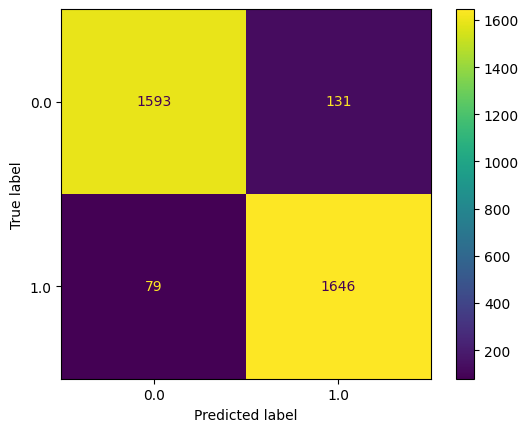

AUC Train: 0.9882921416322

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.82      0.84      0.83       432
         1.0       0.84      0.81      0.83       431

    accuracy                           0.83       863
   macro avg       0.83      0.83      0.83       863
weighted avg       0.83      0.83      0.83       863



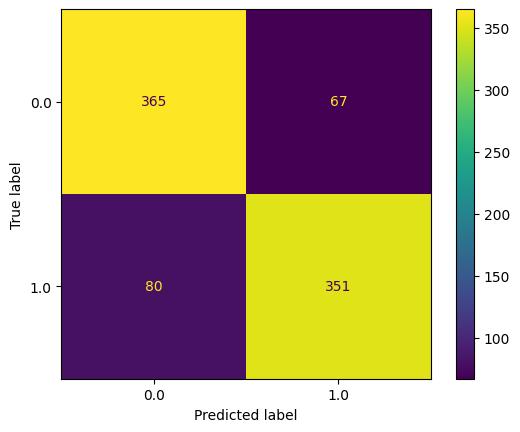

AUC Train: 0.906365472200739


In [27]:
# SMOTENC para df con categorical features
idx_cat_features = [model_df_nooh.columns.get_loc(col) for col in pairings_list]

X_smotenc, y_smotenc = oversample_df(
    df=model_df_nooh,
    sampling_object=SMOTENC,
    random_state=0,
    categorical_features=idx_cat_features
)

results_smotenc = train_test_model(
    X=X_smotenc,
    y=y_smotenc,
    model_object=rf_model,
    test_size=0.2,
    random_state=0,
    stratify=y_smotenc
)

display(Markdown("# SMOTENC"))
print_model_results(results_smotenc)

# SMOTE


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

         0.0       0.95      0.94      0.94      1724
         1.0       0.94      0.95      0.94      1725

    accuracy                           0.94      3449
   macro avg       0.94      0.94      0.94      3449
weighted avg       0.94      0.94      0.94      3449



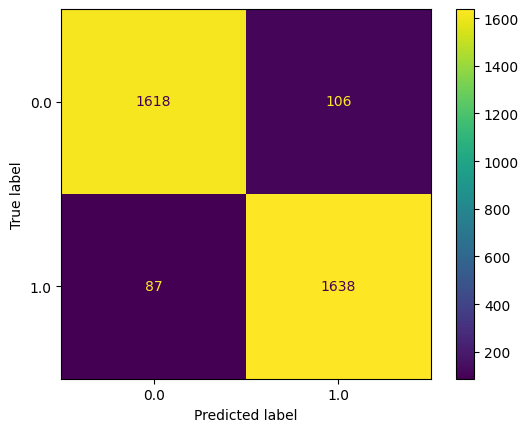

AUC Train: 0.9903207908806616

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.81      0.86      0.84       432
         1.0       0.85      0.80      0.83       431

    accuracy                           0.83       863
   macro avg       0.83      0.83      0.83       863
weighted avg       0.83      0.83      0.83       863



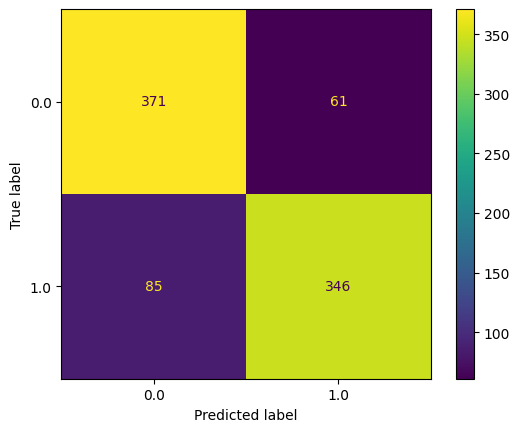

AUC Train: 0.9068058778035575


# ADASYN


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

         0.0       0.96      0.95      0.96      1701
         1.0       0.96      0.96      0.96      1724

    accuracy                           0.96      3425
   macro avg       0.96      0.96      0.96      3425
weighted avg       0.96      0.96      0.96      3425



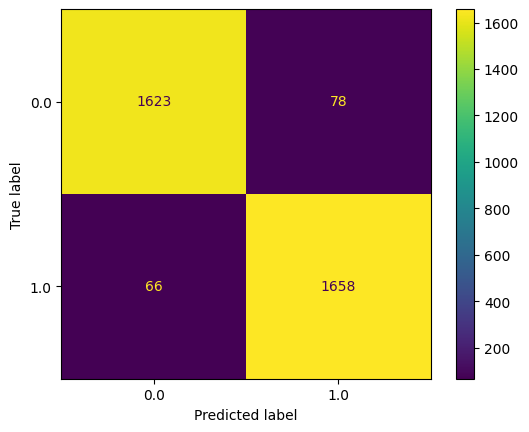

AUC Train: 0.9930218814918479

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.80      0.86      0.83       425
         1.0       0.85      0.78      0.81       432

    accuracy                           0.82       857
   macro avg       0.82      0.82      0.82       857
weighted avg       0.82      0.82      0.82       857



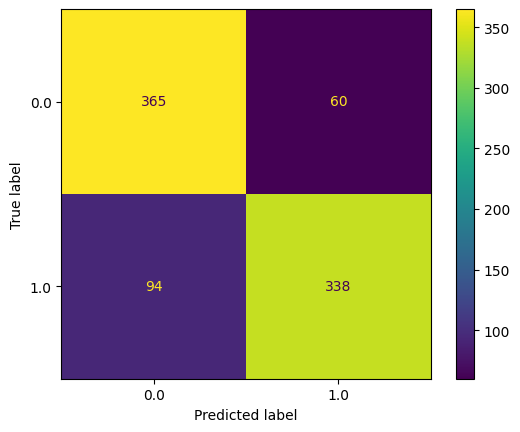

AUC Train: 0.8956508714596949


# BorderlineSMOTE


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

         0.0       0.96      0.93      0.94      1724
         1.0       0.93      0.96      0.95      1725

    accuracy                           0.95      3449
   macro avg       0.95      0.95      0.95      3449
weighted avg       0.95      0.95      0.95      3449



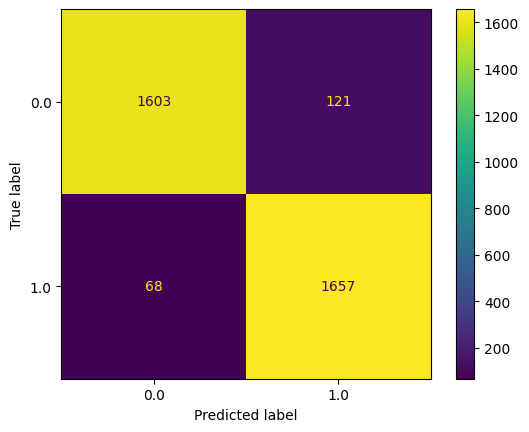

AUC Train: 0.989404149433404

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.82      0.87      0.84       432
         1.0       0.86      0.81      0.83       431

    accuracy                           0.84       863
   macro avg       0.84      0.84      0.84       863
weighted avg       0.84      0.84      0.84       863



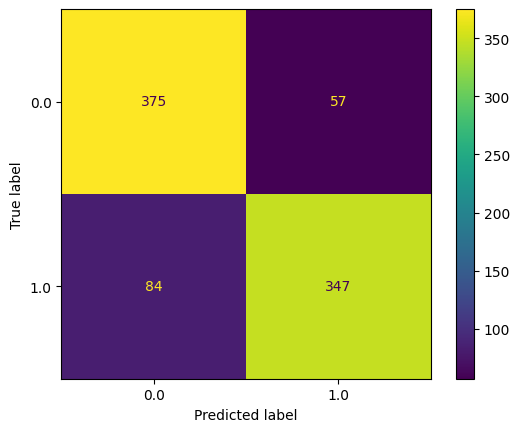

AUC Train: 0.9064782590014608


# SVMSMOTE


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

         0.0       0.98      0.89      0.93      1724
         1.0       0.90      0.98      0.93      1725

    accuracy                           0.93      3449
   macro avg       0.94      0.93      0.93      3449
weighted avg       0.94      0.93      0.93      3449



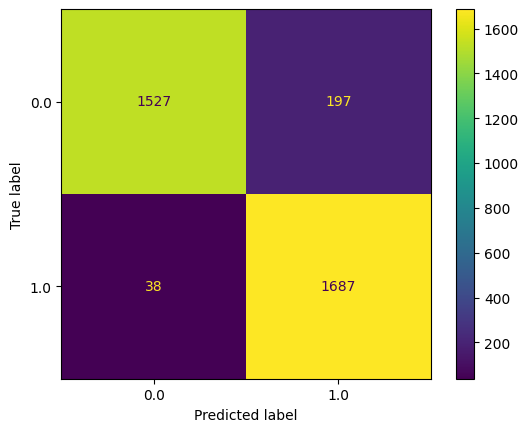

AUC Train: 0.9884693500117689

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.84      0.82      0.83       432
         1.0       0.83      0.85      0.84       431

    accuracy                           0.83       863
   macro avg       0.83      0.83      0.83       863
weighted avg       0.83      0.83      0.83       863



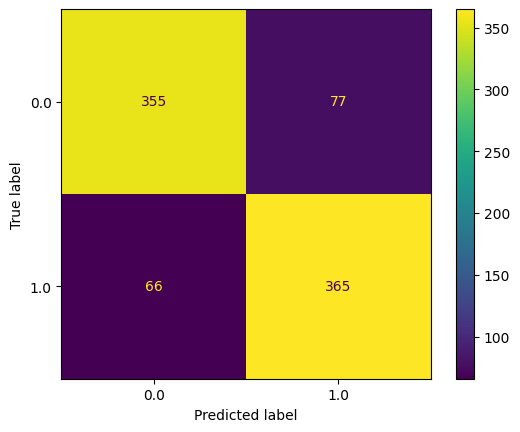

AUC Train: 0.912611712640715


In [25]:
sampling_objects = [SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE]

for obj in sampling_objects:

    X_resampled, y_resampled = oversample_df(
        df=model_df_nocat,
        sampling_object=obj,
        random_state=0,
    )

    results_resampled = train_test_model(
        X=X_resampled,
        y=y_resampled,
        model_object=rf_model,
        test_size=0.2,
        random_state=0,
        stratify=y_resampled
    )

    display(Markdown(f"# {obj.__name__}"))
    print_model_results(results_resampled)

In [ ]:
pca = PCA(n_components=2)

pca.fit_transform(model_df_nocat)


In [ ]:
# Aplicar resto de sampleos y agregar visualización por pca
# Luego seguir con ajuste de hiperparámetros y evaluación económica